In [ ]:
import pandas as pd

df = pd.read_excel("melanoma.csv.xlsx")

# transpose (important!)
df = df.set_index('sample').T

# extract labels
def get_label(sample):
    if sample.endswith("01"):
        return "Primary"
    elif sample.endswith("06"):
        return "Metastatic"
    else:
        return "Other"

df['Label'] = df.index.map(get_label)

print(df['Label'].value_counts())

Label
Metastatic    368
Primary       104
Other           2
Name: count, dtype: int64


In [ ]:
df = df[df['Label'] != "Other"]

In [ ]:
X = df.drop('Label', axis=1)
y = df['Label']

In [ ]:
y = y.map({'Primary': 0, 'Metastatic': 1})

In [ ]:
import numpy as np
X_log = np.log2(X + 1)

In [ ]:
group1 = X_log[y == 0]   # Primary
group2 = X_log[y == 1]   # Metastatic

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [ ]:
from scipy.stats import ttest_ind
import numpy as np

p_values = []
logFC = []

for gene in X_log.columns:
    t, p = ttest_ind(group1[gene], group2[gene], equal_var=False)
    p_values.append(p)

    fc = group2[gene].mean() - group1[gene].mean()
    logFC.append(fc)

In [ ]:
from statsmodels.stats.multitest import multipletests
import numpy as np

# convert to numpy array safely
p_values_np = np.array(p_values)

# replace any nan (just in case)
p_values_np = np.nan_to_num(p_values_np, nan=1.0)

adj_p = multipletests(p_values_np, method='fdr_bh')[1]

In [ ]:
deg_df = pd.DataFrame({
    'Gene': X_log.columns,
    'logFC': logFC,
    'p_value': p_values,
    'adj_p_value': adj_p
})

In [ ]:
print(deg_df.sort_values('p_value').head(10))

         Gene     logFC       p_value   adj_p_value
8413     MMP3 -1.216672  6.493185e-29  1.333051e-24
5670   SHISA3  1.040960  1.894215e-27  1.944412e-23
3530    KRT14 -1.516835  1.174092e-26  8.034705e-23
11153      C7  1.249608  2.506974e-25  1.286704e-21
15436    IRX2 -0.847338  3.169988e-25  1.301597e-21
4071    KRT17 -1.241265  7.745804e-25  2.650356e-21
18174    SPIC  0.582691  2.133680e-23  6.257779e-20
10311    DMKN -0.627304  3.630727e-23  9.317353e-20
10124  FAM83H -0.171048  1.310444e-22  2.829444e-19
9046     MMP1 -0.639096  1.378200e-22  2.829444e-19


In [ ]:
deg_filtered = deg_df[
    (deg_df['adj_p_value'] < 0.05)
]

print("Significant genes:", len(deg_filtered))

Significant genes: 8753


In [ ]:
top_genes = deg_df.sort_values(by='p_value').head(100)

print("Top genes:", len(top_genes))

Top genes: 100


In [ ]:
print("Up:", sum((deg_df['logFC'] > 0.5) & (deg_df['p_value'] < 0.05)))
print("Down:", sum((deg_df['logFC'] < -0.5) & (deg_df['p_value'] < 0.05)))

Up: 102
Down: 387


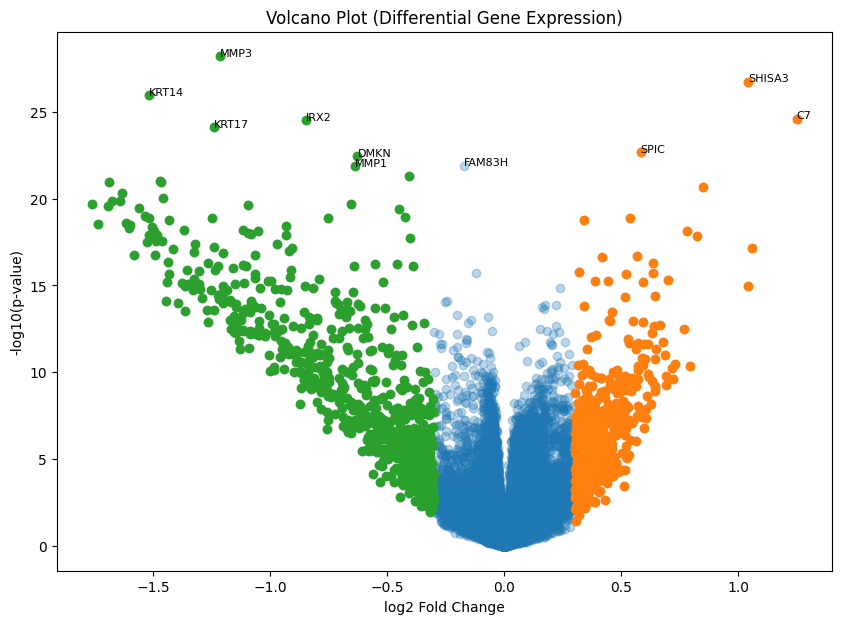

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))

up = (deg_df['logFC'] > 0.3) & (deg_df['p_value'] < 0.1)
down = (deg_df['logFC'] < -0.3) & (deg_df['p_value'] < 0.1)

plt.scatter(deg_df['logFC'], -np.log10(deg_df['p_value']), alpha=0.3)

plt.scatter(deg_df['logFC'][up], -np.log10(deg_df['p_value'][up]))
plt.scatter(deg_df['logFC'][down], -np.log10(deg_df['p_value'][down]))

# label top genes
top10 = deg_df.sort_values('p_value').head(10)

for i in range(len(top10)):
    plt.text(
        top10['logFC'].iloc[i],
        -np.log10(top10['p_value'].iloc[i]),
        top10['Gene'].iloc[i],
        fontsize=8
    )

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (Differential Gene Expression)")

plt.show()

The volcano plot shows differentially expressed genes between primary and metastatic melanoma. Genes on the right are upregulated in metastatic samples, while those on the left are downregulated. Highly significant genes appear at the top.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
selected_gene_names = top_genes['Gene'].values

In [ ]:
final_df = X_scaled[selected_gene_names].copy()
final_df['Label'] = y

final_df.to_csv("final_ml_dataset.csv")

In [ ]:
import pandas as pd

geo = pd.read_csv("GSE65904_series_matrix.txt", sep="\t", comment='!', index_col=0)

geo.head()

,GSM1608593,GSM1608594,GSM1608595,GSM1608596,GSM1608597,GSM1608598,GSM1608599,GSM1608600,GSM1608601,GSM1608602,...,GSM1608797,GSM1608798,GSM1608799,GSM1608800,GSM1608801,GSM1608802,GSM1608803,GSM1608804,GSM1608805,GSM1608806
ID_REF,,,,,,,,,,,,,,,,,,,,,
ILMN_1343291,20242.63000,18935.2700,19552.3800,19896.1200,19005.4400,17016.9300,22596.7300,15030.4100,18041.5500,19529.4000,...,18362.7900,21273.14000,19269.5800,24052.6300,18131.7200,24622.0400,20375.0600,21320.2100,23377.9100,22908.3800
ILMN_1343295,14811.77000,4021.3530,11045.8800,10270.4400,13411.0100,12145.0300,14402.2700,7648.6830,8215.6400,5382.5420,...,4745.1040,11135.00000,3442.8020,10951.8500,12423.2000,7171.6980,12417.3600,11046.7100,13101.5400,7983.1100
ILMN_1651199,112.52470,113.6134,111.2679,102.3197,111.0804,113.2056,115.6117,105.3319,114.4789,108.2449,...,100.2077,97.97456,103.2224,105.0411,132.4627,112.9750,110.5833,115.1380,111.1291,112.0233
ILMN_1651209,117.35510,121.8252,134.9322,114.8984,125.0771,106.5068,112.0233,110.4959,110.5104,140.1753,...,117.4235,114.50530,112.5418,125.8525,118.2445,126.7515,123.4797,113.1950,122.6584,122.2967
ILMN_1651210,96.19225,119.8218,113.6980,123.5953,105.4653,108.6502,131.6439,110.9349,108.9948,104.4706,...,109.0654,162.13110,117.0967,120.3406,121.6592,107.9066,111.2044,115.9533,110.2902,128.4892


In [ ]:
geo = geo.T

In [ ]:
import pandas as pd

# load GEO file (removes metadata automatically)
geo = pd.read_csv("GSE65904_series_matrix.txt", sep="\t", comment='!', index_col=0)

# transpose (important)
geo = geo.T

# save cleaned file
geo.to_csv("geo_cleaned.csv")

print("Saved as geo_cleaned.csv")

Saved as geo_cleaned.csv


In [ ]:
print(geo.shape)
geo.head()

(214, 47323)


ID_REF,ILMN_1343291,ILMN_1343295,ILMN_1651199,ILMN_1651209,ILMN_1651210,ILMN_1651221,ILMN_1651228,ILMN_1651229,ILMN_1651230,ILMN_1651232,...,ILMN_3311145,ILMN_3311150,ILMN_3311155,ILMN_3311160,ILMN_3311165,ILMN_3311170,ILMN_3311175,ILMN_3311180,ILMN_3311185,ILMN_3311190
GSM1608593,20242.63,14811.770,112.5247,117.3551,96.19225,131.2527,10448.180,332.9761,109.9601,154.7977,...,125.2866,99.68437,111.7781,120.2231,136.4091,109.2455,119.2020,132.1390,113.6272,129.6776
GSM1608594,18935.27,4021.353,113.6134,121.8252,119.82180,117.3231,10628.630,277.0179,112.8915,123.0758,...,120.5092,102.08770,117.2939,116.4310,118.0043,110.9509,118.0924,116.9194,118.9910,111.3289
GSM1608595,19552.38,11045.880,111.2679,134.9322,113.69800,122.3191,7409.818,429.4903,103.5508,113.3354,...,112.7520,110.35180,119.7662,109.2005,116.1625,109.3342,115.4904,113.6154,112.4370,136.8894
GSM1608596,19896.12,10270.440,102.3197,114.8984,123.59530,112.9925,12968.840,293.8278,107.2707,108.7222,...,106.3610,112.50760,146.4712,117.0091,111.8252,109.4484,107.4294,122.9829,117.8893,129.0555
GSM1608597,19005.44,13411.010,111.0804,125.0771,105.46530,118.1001,12190.210,648.9417,111.0762,113.4453,...,182.6859,105.66150,123.9990,154.9974,116.2951,128.4656,126.3383,111.8570,116.9895,117.0131


In [ ]:
import pandas as pd

geo = pd.read_csv(
    "GSE65904_series_matrix.txt",
    sep="\t",
    comment='!',
    index_col=0
)


annot = pd.read_csv("GPL10558-50081.txt", sep="\t", comment='#')
annot = annot[['ID', 'Symbol']]


geo.index = geo.index.astype(str).str.strip()
annot['ID'] = annot['ID'].astype(str).str.strip()

geo['ID'] = geo.index

geo = geo.merge(annot, on='ID', how='left')

# check mapping
print("Matched probes:", geo['Symbol'].notna().sum())

geo = geo.dropna(subset=['Symbol'])


geo = geo.drop(columns=['ID'])


geo = geo.groupby('Symbol').mean(numeric_only=True)

geo_final = geo.T


print("Final shape:", geo_final.shape)
print("Example genes:", list(geo_final.columns[:10]))

geo_final.head()

Matched probes: 44053
Final shape: (214, 31426)
Example genes: ['1-Dec', '1-Mar', '10-Mar', '11-Mar', '2-Mar', '3-Mar', '4-Mar', '5-Mar', '6-Mar', '7-Mar']


Symbol,1-Dec,1-Mar,10-Mar,11-Mar,2-Mar,3-Mar,4-Mar,5-Mar,6-Mar,7-Mar,...,ZYG11B,ZYX,ZZEF1,ZZZ3,dJ222E13.2,dJ341D10.1,gm127,psiTPTE22,rab1c,tAKR
GSM1608593,111.6291,232.12120,106.28515,112.7058,289.800475,196.401333,114.97500,240.25510,1495.3980,1609.485,...,998.9297,1340.56060,443.4439,891.63390,117.9162,300.3302,113.8299,114.63315,112.7040,100.66386
GSM1608594,98.3802,612.17625,106.61000,109.7434,247.364525,413.206367,98.74764,204.93505,1022.8230,1319.234,...,501.1589,570.24945,211.2084,804.07995,107.5302,225.1704,142.6239,121.73440,112.8754,116.37520
GSM1608595,107.1824,192.32890,112.37370,108.1932,245.471000,138.227633,114.07660,238.69250,678.4952,1998.189,...,1468.1080,966.35000,316.8802,1369.68600,110.9912,370.7296,129.8319,114.39145,107.3800,106.37845
GSM1608596,117.6200,278.00505,108.26010,109.0667,245.153375,412.340533,103.62660,206.49705,1382.3380,1117.894,...,1312.7930,1001.14345,476.6028,675.56070,120.2153,236.1563,118.5272,108.09030,111.5731,106.74575
GSM1608597,117.0205,148.38195,122.00560,119.2202,269.039975,192.891267,109.22490,238.40725,1646.4750,1017.482,...,1236.2020,1196.87680,323.7353,582.74455,125.4027,280.1674,122.6921,119.14945,130.9203,107.63030


In [ ]:
# remove columns that look like dates
geo_final = geo_final.loc[:, ~geo_final.columns.str.contains('-')]

In [ ]:
print(list(geo_final.columns[:20]))

['7A5', 'A1BG', 'A1CF', 'A26C3', 'A2BP1', 'A2LD1', 'A2M', 'A2ML1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACS', 'AACSL', 'AADAC', 'AADACL1', 'AADACL2', 'AADACL3', 'AADACL4']


In [ ]:
common_genes = list(set(selected_gene_names).intersection(set(geo_final.columns)))

geo_selected = geo_final[common_genes]

print("Final usable genes:", len(common_genes))

Final usable genes: 99


In [ ]:
geo_selected.to_csv("geo_for_model.csv")

from google.colab import files
files.download("geo_for_model.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>